In [2]:
import matplotlib.pyplot as plt
import torch
import ase
import numpy as np
import scipy
from ase.build import molecule, bulk, make_supercell
from ase.neighborlist import neighbor_list
import pandas as pd
from tqdm.notebook import tqdm
import seaborn as sns

import molpot as mpot
from molpot import alias

from torch_nl import compute_neighborlist, compute_neighborlist_n2, ase2data
from torch_nl.timer import timeit

/opt/conda/lib/python3.11/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


## Data Prepare

In [3]:
frame = bulk('Si', 'diamond', a=4, cubic=True)
aa = torch.arange(1, 10, 2)
Ps = torch.cartesian_prod(aa,aa,aa)
Ps = Ps[torch.sort(Ps.sum(dim=1)).indices].to(torch.long).numpy()
frames = []
n_atoms = []
for P in Ps:
    frames.append(make_supercell(frame, np.diag(P)))
    n_atoms.append(len(frames[-1]))
n_atoms = np.array(n_atoms)

In [4]:
n_atoms

array([   8,   24,   24,   24,   72,   72,   40,   40,   72,   40,   56,
        120,   56,  216,  120,  120,  120,  120,   56,  120,  200,  168,
        360,   72,  360,  168,  168,  168,  200,  168,   72,  200,   72,
        168,  360,  504,  600,  216,  280,  504,  600,  280,  280,  504,
        216,  280,  280,  216,  216,  216,  216,  600,  280,  392,  360,
        360,  840,  648,  392,  840,  360,  840, 1000,  648,  840,  360,
        648,  360,  840,  392,  360,  840,  504,  504, 1176, 1176, 1080,
       1400,  504, 1176,  504, 1080, 1080, 1400, 1080, 1080,  504,  504,
       1400, 1080,  648, 1800,  648,  648, 1512, 1800, 1512, 1512, 1960,
       1960, 1960, 1512, 1512, 1512, 1800, 1944, 2520, 2520, 2520, 2520,
       1944, 2520, 2520, 2744, 1944, 3240, 3528, 3528, 3240, 3528, 3240,
       4536, 4536, 4536, 5832])

In [6]:
cutoff = 4

## ASE Reference

In [7]:
tag = "ASE"
datas = []
for frame in tqdm(frames):
    timing = timeit(neighbor_list, ['ijS', frame, cutoff], tag=tag, warmup=1, nit=10)
    data = timing.dumps()
    i,j,S = neighbor_list('ijS', frame, cutoff)
    n_neighbor = np.bincount(i).mean()
    data.update(n_atom=len(frame), n_neighbor_per_atom_avg=int(n_neighbor))
    data.pop('samples')
    datas.append(data)

  0%|          | 0/125 [00:00<?, ?it/s]

## Torch_nl benchmark

In [8]:
from torch_nl import compute_neighborlist, compute_neighborlist_n2, ase2data
from torch_nl.timer import timeit

In [9]:
tags = [
    # "torch_nl O(n^2) CPU", 
    # "torch_nl O(n^2) GPU", 
    "torch_nl O(n) CPU", 
    "torch_nl O(n) GPU"
]
for tag in tqdm(tags):
    if "CPU" in tag:
        device = 'cpu'
    elif "GPU" in tag:
        device = 'cuda'
        
    if 'O(n^2)' in tag:
        nl_func = compute_neighborlist_n2
    elif 'O(n)' in tag:
        nl_func = compute_neighborlist

    for frame in tqdm(frames):
        pos, cell, pbc, batch, n_atoms = ase2data([frame], device=device)
        timing = timeit(nl_func, [cutoff, pos, cell, pbc, batch], tag=tag, warmup=3, nit=10)
        data = timing.dumps()
        data.pop('samples')
        mapping, mapping_batch, shifts_idx = nl_func(cutoff, pos, cell, pbc, batch)
        n_neighbor = np.bincount(mapping[0].cpu().numpy()).mean()
        data.update(n_atom=len(frame), n_neighbor_per_atom_avg=int(n_neighbor))
        datas.append(data)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

## Op benchmark

In [10]:
from molpot_op import get_neighbor_pairs

In [11]:
tags = ['op CPU', 'op GPU']
# op_datas = []
for tag in tags:
    for frame in tqdm(frames):
        if "CPU" in tag:
            device = 'cpu'
        elif "GPU" in tag:
            device = 'cuda'
        pos, cell, pbc, batch, n_atoms = ase2data([frame], device=device)
        if any(cell.diag() < cutoff * 2):
            continue
        timing = timeit(get_neighbor_pairs, [pos, cutoff, -1, cell], tag=tag, warmup=3, nit=10)
        data = timing.dumps()
        data.pop('samples')
        neighbors, deltas, distances, n_neighbor = get_neighbor_pairs(pos, cutoff, -1, cell)
        data.update(n_atom=len(frame), n_neighbor_per_atom_avg=int(n_neighbor))
        datas.append(data)

  0%|          | 0/125 [00:00<?, ?it/s]

[W830 09:45:39.107192913 LinearAlgebra.cpp:3072] Warning: at::frobenius_norm is deprecated and it is just left for JIT compatibility. It will be removed in a future PyTorch release. Please use `linalg.vector_norm(A, 2., dim, keepdim)` instead (function operator())


  0%|          | 0/125 [00:00<?, ?it/s]

## Summary

In [12]:
df = pd.DataFrame(datas)


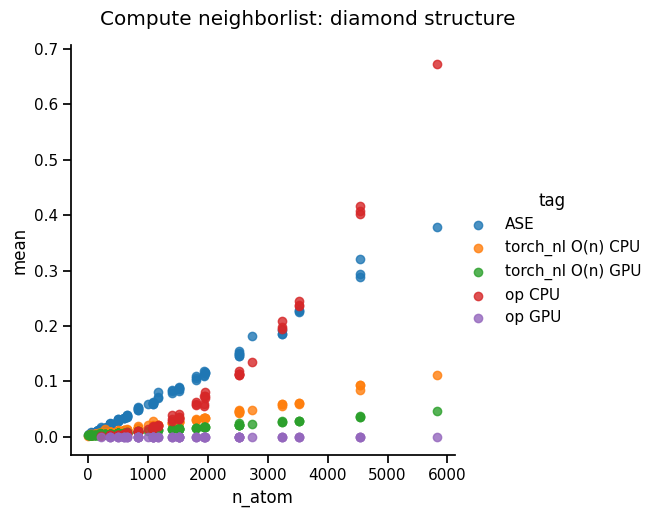

In [13]:
with sns.plotting_context("notebook"):
    g = sns.lmplot(data=df, x='n_atom', y='mean', hue='tag', fit_reg=False)
    g.set_axis_labels('n_atom', 'mean')
    g.fig.suptitle("Compute neighborlist: diamond structure", y=1.03)
    # g.savefig('diamond_benchmark.png', dpi=300, bbox_inches='tight')